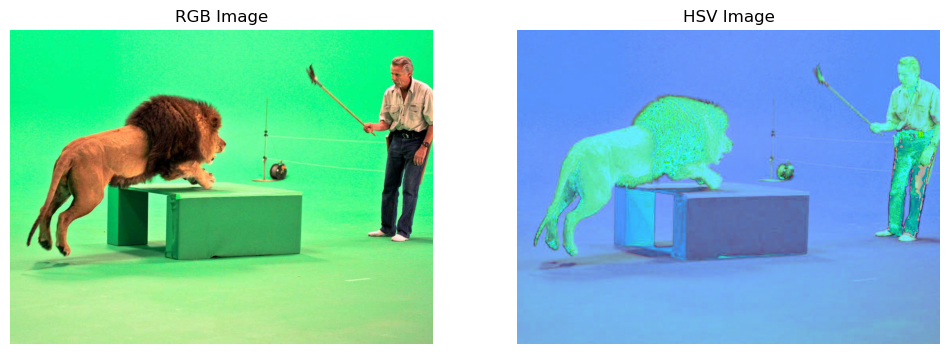

In [1]:
import cv2
import matplotlib.pyplot as plt

lion_rgb = cv2.imread('data/01/lion.jpg')
lion_hsv = cv2.imread('data/01/lionHSV.jpg')

lion_rgb = cv2.cvtColor(lion_rgb, cv2.COLOR_BGR2RGB)

lion_hsv = cv2.cvtColor(lion_hsv, cv2.COLOR_BGR2HSV)

fig, axes = plt.subplots(1, 2, figsize=(12, 6))

axes[0].imshow(lion_rgb)
axes[0].set_title('RGB Image')
axes[0].axis('off')

axes[1].imshow(lion_hsv)
axes[1].set_title('HSV Image')
axes[1].axis('off')

plt.show()

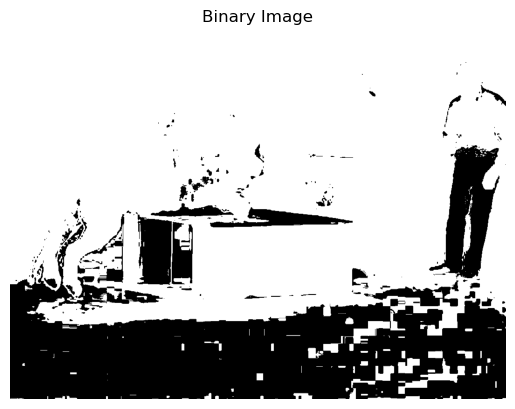

In [2]:
h_channel = lion_hsv[:, :, 0]
h_channel_normalized = h_channel / 255.0
binary_image = ((h_channel_normalized > 0.22) & (h_channel_normalized < 0.45)).astype(int)

plt.imshow(binary_image, cmap='gray')
plt.title('Binary Image')
plt.axis('off')
plt.show()

(791, 1064)


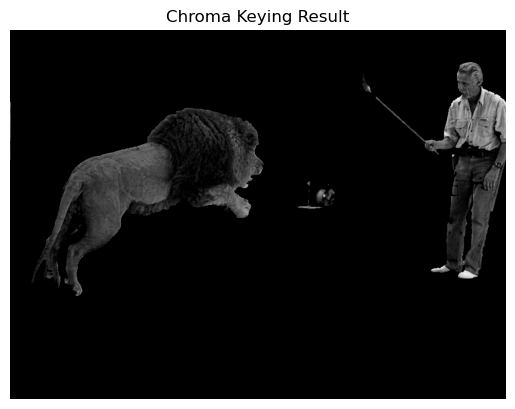

In [13]:
import numpy as np

data = np.loadtxt('data/01/data.txt')

print(lion_rgb.shape[:2]) # (791, 1064)

v_1 = data[:, 0] # (841624,)
v_2 = data[:, 1] # (841624,)
v_3 = data[:, 2] # (841624,)
v_B = data[:, 3] # (841624,)

def chroma_keying(lion_rgb, v_1, v_2, v_3, v_B):
    m, n = lion_rgb.shape[:2]
    id_vB = np.nonzero(v_B)[0]
    
    v_1 = np.reshape(v_1, (m, n))
    v_2 = np.reshape(v_2, (m, n))
    v_3 = np.reshape(v_3, (m, n))
    v_B = np.reshape(v_B, (m, n))

    for b in range(3):
        v = [v_1, v_2, v_3][b]
        v.flat[id_vB] = 0

    Kb = np.zeros((m, n))
    for j in range(n):
        count = 0
        for i in range((j - 1) * m, j * m):
            Kb[count, j] = [v_1, v_2, v_3][b].flat[i]
            count += 1

    K = np.stack((Kb, Kb, Kb), axis=-1)
    K = np.uint8(K)

    return K

result = chroma_keying(lion_rgb, v_1, v_2, v_3, v_B)

plt.imshow(result)
plt.title('Chroma Keying Result')
plt.axis('off')
plt.show()